# Country-Level Analysis

Goal:
- Top destination countries for German emigrants
- Which countries have the highest return rates
- How stable or volatile migration to specific countries is

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
# 02 Conig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("whitegrid")

In [3]:
# 03 Load country dataset
df_country = pd.read_csv("../data/processed/return_rate_country.csv")

df_country.head()

,year,country,emigration,immigration,return_rate_country
0,2000,Afghanistan,16,13,0.812500
1,2000,Albanien,44,45,1.022727
2,2000,Algerien,75,64,0.853333
3,2000,Andorra,14,12,0.857143
4,2000,Angola,19,17,0.894737


In [4]:
df_country.info()

<class 'pandas.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 2924 non-null   int64  
 1   country              2924 non-null   str    
 2   emigration           2924 non-null   int64  
 3   immigration          2924 non-null   int64  
 4   return_rate_country  2896 non-null   float64
dtypes: float64(1), int64(3), str(1)
memory usage: 114.3 KB


In [5]:
# Top Destination Countries
top_destinations = (
    df_country
    .groupby("country")["emigration"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_destinations

country
Ungeklärt / Ohne Angabe    1337683
Schweiz                     446118
Vereinigte Staaten          302241
Österreich                  256819
Polen                       191731
Vereinigtes Königreich      182548
Spanien                     175919
Frankreich                  160136
Türkei                      112906
Niederlande                  89775
Name: emigration, dtype: int64

<Axes: title={'center': 'Top Destination Countries for German Emigrants'}, xlabel='country'>

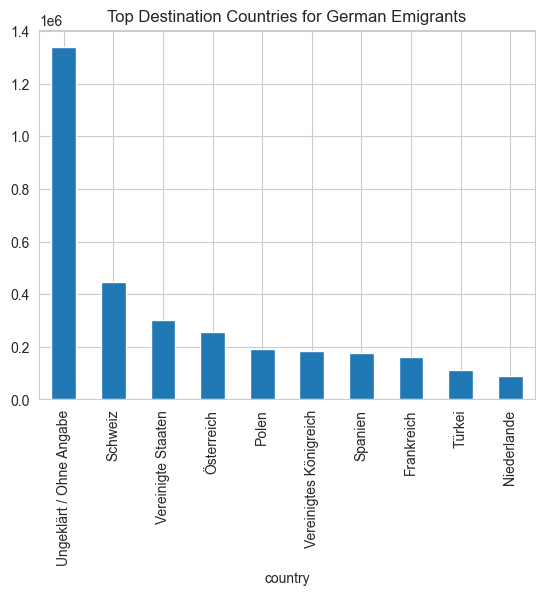

In [6]:
# Visual
top_destinations.plot(kind="bar", title="Top Destination Countries for German Emigrants")

### Top Destination Countries

The analysis shows the countries that received the highest number of German emigrants between 2000 and 2024.

This helps identify long-term migration preferences and potential economic or cultural migration corridors.

In [7]:
# Average Return Rate by Country
return_rate_country_avg = (
    df_country
    .groupby("country")["return_rate_country"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

return_rate_country_avg

country
Jemen                                          inf
Kasachstan                               16.234412
Kirgisistan                               9.145921
Usbekistan                                8.262336
Russische Föderation                      6.429067
Ukraine                                   5.949912
Sudan (ohne Südsudan) (ab 09.07.2011)     3.800000
Belarus                                   2.837353
Venezuela, Bolivarische Republik          2.351963
Armenien                                  2.134954
Name: return_rate_country, dtype: float64

<Axes: title={'center': 'Highest Average Return Rate by Country'}, xlabel='country'>

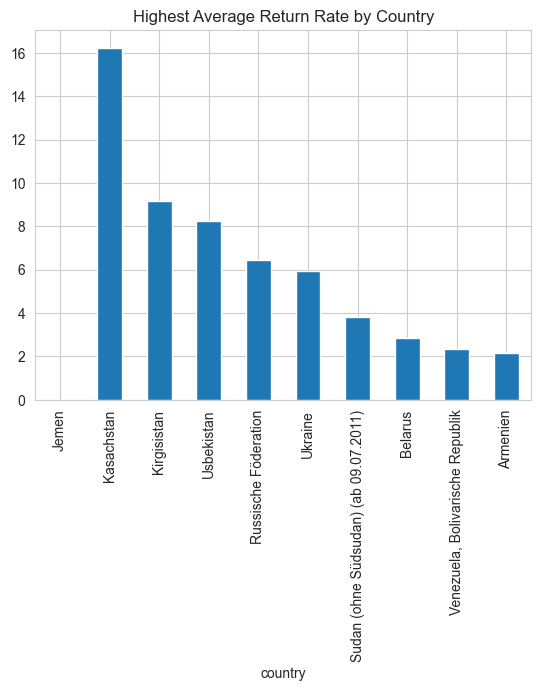

In [8]:
return_rate_country_avg.plot(kind="bar", title="Highest Average Return Rate by Country")

### Countries with Highest Return Rates

Some countries show significantly higher return rates, suggesting shorter migration cycles or temporary work migration patterns.

<Axes: title={'center': 'Migration Trends for Top Destination Countries'}, xlabel='year'>

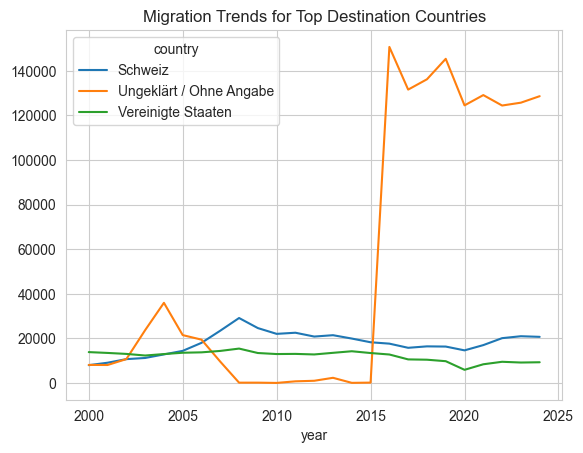

In [9]:
# Migration Trend of top 3 countries
top3 = top_destinations.index[:3]

df_top3 = df_country[df_country["country"].isin(top3)]

pivot_top3 = df_top3.pivot_table(
    index="year",
    columns="country",
    values="emigration"
)

pivot_top3.plot(title="Migration Trends for Top Destination Countries")

### Migration Trends for Major Destination Countries

The time-series analysis highlights how migration to major destinations evolved over time.

This allows identification of migration waves and potential external drivers.

## Top Destination Countries

To understand the main migration patterns, we first identify the countries with the highest total emigration from Germany.

In [12]:
top_countries = (
    df_country
    .groupby("emigration")["return_rate_country"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

emigration
0            inf
474    91.350211
17     86.529412
557    73.989228
41     70.292683
529    64.204159
49     58.061224
26     44.153846
74     42.905405
571    41.255692
Name: return_rate_country, dtype: float64